In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## LOAD DATASET

In [2]:
df = pd.read_csv(r"C:\Users\sarth\OneDrive\Desktop\Social Media EDA Analysis\Teen_Mental_Health_Dataset.csv")

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(df.head())

✅ Dataset loaded!
Shape: (1200, 13)
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                     

In [3]:
print("="*50)
print("DATASET INFO:")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("STATISTICAL SUMMARY:")
print("="*50)
print(df.describe())

DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 

## Check Missing Values

In [4]:
print("="*50)
print("MISSING VALUES:")
print("="*50)
print(df.isnull().sum())

MISSING VALUES:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


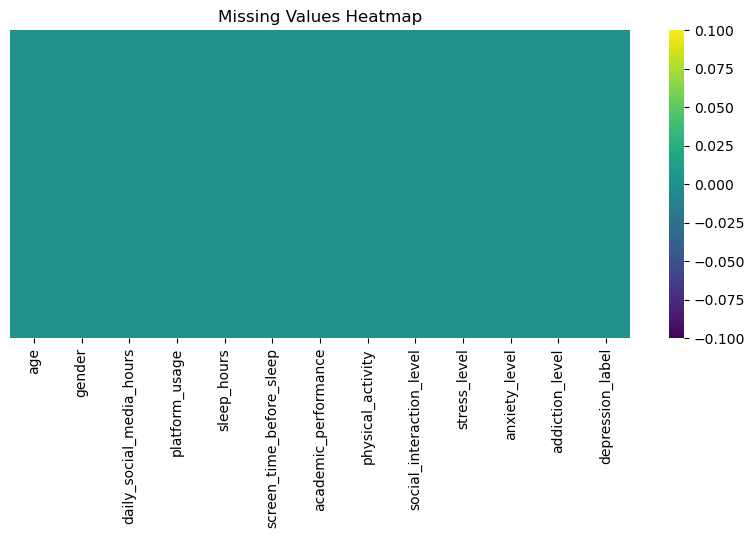

In [5]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## Target Variable Analysis

In [6]:
print("="*50)
print("DEPRESSION LABEL ANALYSIS:")
print("="*50)

# Count depression cases
depression_counts = df['depression_label'].value_counts()
print(f"No Depression (0): {depression_counts[0]} students")
print(f"Depression (1): {depression_counts[1]} students")
print(f"Depression Rate: {(depression_counts[1]/len(df))*100:.2f}%")

DEPRESSION LABEL ANALYSIS:
No Depression (0): 1169 students
Depression (1): 31 students
Depression Rate: 2.58%


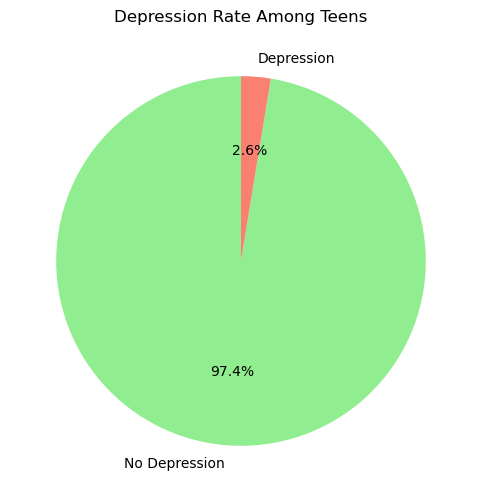

In [7]:
# Pie chart
plt.figure(figsize=(6,6))
plt.pie(depression_counts, labels=['No Depression', 'Depression'], 
        autopct='%1.1f%%', colors=['lightgreen', 'salmon'], startangle=90)
plt.title('Depression Rate Among Teens')
plt.show()

## Gender Distribution

In [8]:
print("="*50)
print("GENDER ANALYSIS:")
print("="*50)

# Gender counts
gender_counts = df['gender'].value_counts()
print(gender_counts)

GENDER ANALYSIS:
gender
male      615
female    585
Name: count, dtype: int64



Depression Rate by Gender:
depression_label          0         1
gender                               
female            97.094017  2.905983
male              97.723577  2.276423


Text(0, 0.5, 'Count')

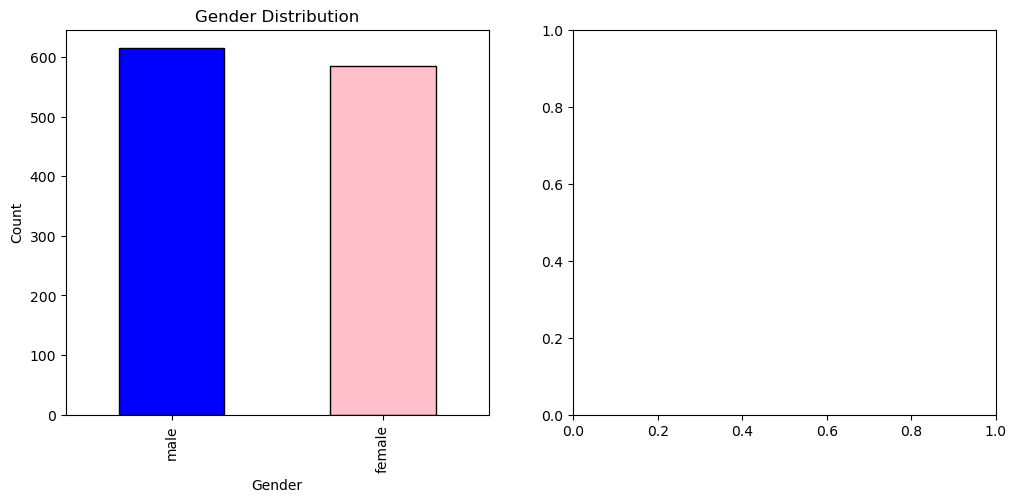

In [9]:
# Gender vs Depression
gender_depression = pd.crosstab(df['gender'], df['depression_label'], normalize='index') * 100
print("\nDepression Rate by Gender:")
print(gender_depression)

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender distribution
gender_counts.plot(kind='bar', ax=axes[0], color=['blue', 'pink'], edgecolor='black')
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

<Figure size 800x600 with 0 Axes>

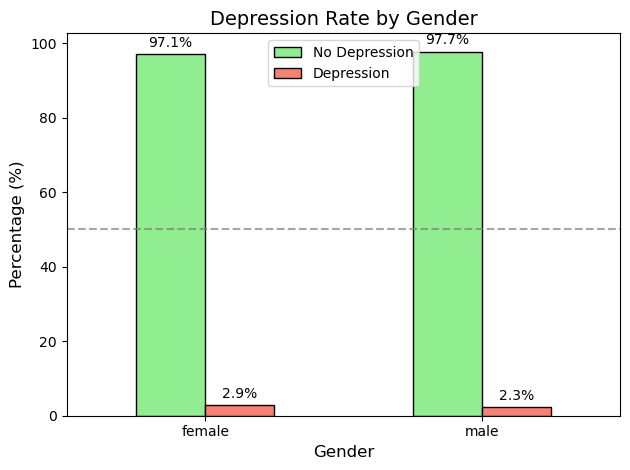

In [10]:
# CELL 3: Plot
plt.figure(figsize=(8, 6))
gender_depression.plot(kind='bar', color=['lightgreen', 'salmon'], edgecolor='black')
plt.title('Depression Rate by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(['No Depression', 'Depression'])
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

# Add labels on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

## Platform Usage Analysis

In [11]:
print("="*50)
print("SOCIAL MEDIA PLATFORM ANALYSIS:")
print("="*50)

# Platform distribution
platform_counts = df['platform_usage'].value_counts()
print("Platform Usage:")
print(platform_counts)

# Platform vs Depression
platform_depression = pd.crosstab(df['platform_usage'], df['depression_label'], normalize='index') * 100
print("\nDepression Rate by Platform:")
print(platform_depression)

SOCIAL MEDIA PLATFORM ANALYSIS:
Platform Usage:
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

Depression Rate by Platform:
depression_label          0         1
platform_usage                       
Both              97.698210  2.301790
Instagram         97.566910  2.433090
TikTok            96.984925  3.015075


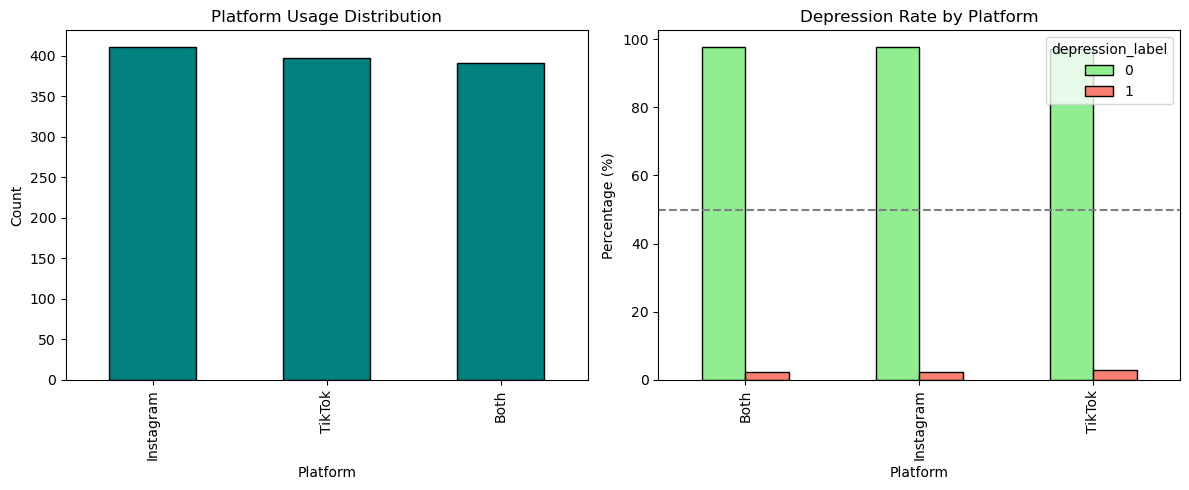

In [12]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

platform_counts.plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Platform Usage Distribution')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Count')

platform_depression.plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'], edgecolor='black')
axes[1].set_title('Depression Rate by Platform')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Percentage (%)')
axes[1].axhline(y=50, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

## Social Media Hours Analysis

In [13]:
print("="*50)
print("SOCIAL MEDIA HOURS ANALYSIS:")
print("="*50)

# Average social media hours
print(f"Average daily social media hours: {df['daily_social_media_hours'].mean():.2f} hours")
print(f"Maximum: {df['daily_social_media_hours'].max():.2f} hours")
print(f"Minimum: {df['daily_social_media_hours'].min():.2f} hours")

# Compare depressed vs non-depressed
depressed_hours = df[df['depression_label'] == 1]['daily_social_media_hours'].mean()
non_depressed_hours = df[df['depression_label'] == 0]['daily_social_media_hours'].mean()
print(f"\nDepressed teens average: {depressed_hours:.2f} hours/day")
print(f"Non-depressed teens average: {non_depressed_hours:.2f} hours/day")

SOCIAL MEDIA HOURS ANALYSIS:
Average daily social media hours: 4.54 hours
Maximum: 8.00 hours
Minimum: 1.00 hours

Depressed teens average: 6.72 hours/day
Non-depressed teens average: 4.48 hours/day


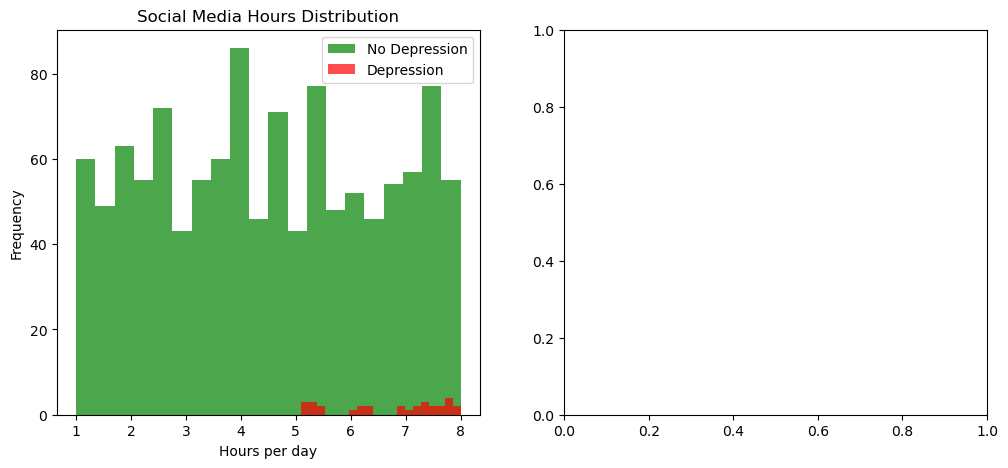

In [14]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(df[df['depression_label']==0]['daily_social_media_hours'], bins=20, alpha=0.7, label='No Depression', color='green')
axes[0].hist(df[df['depression_label']==1]['daily_social_media_hours'], bins=20, alpha=0.7, label='Depression', color='red')
axes[0].set_title('Social Media Hours Distribution')
axes[0].set_xlabel('Hours per day')
axes[0].set_ylabel('Frequency')
axes[0].legend()

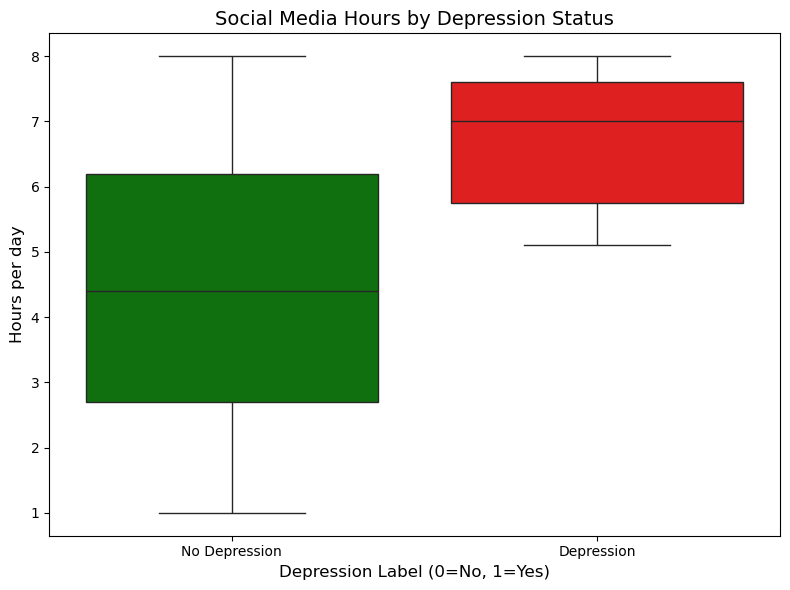

In [15]:
fig = plt.figure(figsize=(8, 6))

# Boxplot graph
sns.boxplot(x='depression_label', y='daily_social_media_hours', data=df, palette=['green', 'red'])

plt.title('Social Media Hours by Depression Status', fontsize=14)
plt.xlabel('Depression Label (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Hours per day', fontsize=12)
plt.xticks([0, 1], ['No Depression', 'Depression'])

plt.tight_layout()
plt.show()

## Sleep Analysis

In [16]:
print("="*50)
print("SLEEP ANALYSIS:")
print("="*50)

print(f"Average sleep hours: {df['sleep_hours'].mean():.2f} hours")
print(f"Average screen time before sleep: {df['screen_time_before_sleep'].mean():.2f} hours")

# Compare by depression
depressed_sleep = df[df['depression_label'] == 1]['sleep_hours'].mean()
non_depressed_sleep = df[df['depression_label'] == 0]['sleep_hours'].mean()
print(f"\nDepressed teens sleep: {depressed_sleep:.2f} hours")
print(f"Non-depressed teens sleep: {non_depressed_sleep:.2f} hours")


SLEEP ANALYSIS:
Average sleep hours: 6.45 hours
Average screen time before sleep: 1.74 hours

Depressed teens sleep: 4.76 hours
Non-depressed teens sleep: 6.49 hours


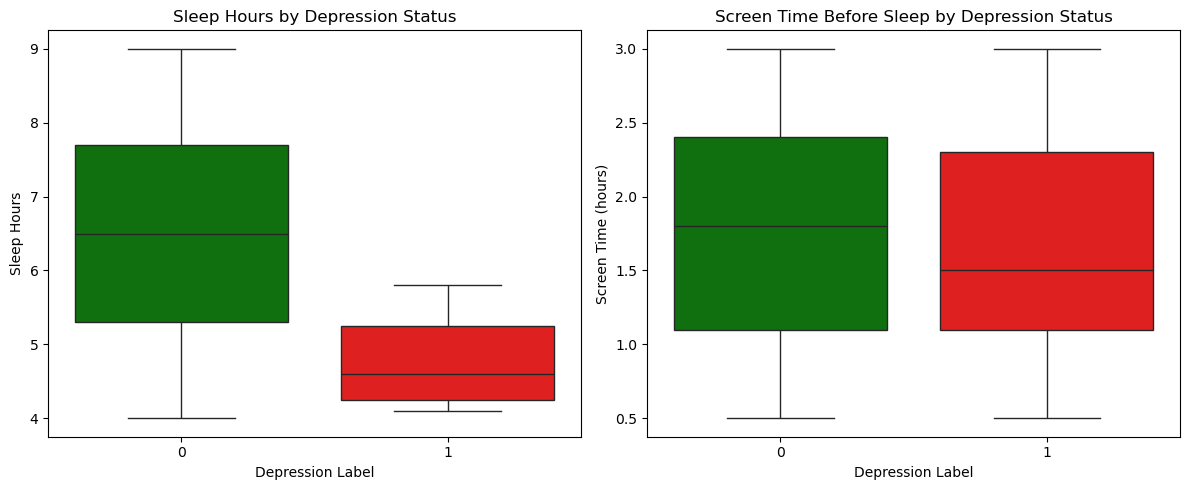

In [17]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='depression_label', y='sleep_hours', data=df, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Sleep Hours by Depression Status')
axes[0].set_xlabel('Depression Label')
axes[0].set_ylabel('Sleep Hours')

sns.boxplot(x='depression_label', y='screen_time_before_sleep', data=df, ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Screen Time Before Sleep by Depression Status')
axes[1].set_xlabel('Depression Label')
axes[1].set_ylabel('Screen Time (hours)')

plt.tight_layout()
plt.show()

## Mental Health Metrics (Stress, Anxiety, Addiction)

In [18]:
print("="*50)
print("MENTAL HEALTH METRICS:")
print("="*50)

metrics = ['stress_level', 'anxiety_level', 'addiction_level']

print("\nAverage Scores (All Teens):")
for metric in metrics:
    print(f"  {metric}: {df[metric].mean():.2f}/10")

print("\nDepressed vs Non-Depressed:")
for metric in metrics:
    depressed = df[df['depression_label'] == 1][metric].mean()
    non_depressed = df[df['depression_label'] == 0][metric].mean()
    print(f"\n  {metric}:")
    print(f"    Depressed: {depressed:.2f}/10")
    print(f"    Non-depressed: {non_depressed:.2f}/10")

MENTAL HEALTH METRICS:

Average Scores (All Teens):
  stress_level: 5.45/10
  anxiety_level: 5.64/10
  addiction_level: 5.57/10

Depressed vs Non-Depressed:

  stress_level:
    Depressed: 8.48/10
    Non-depressed: 5.37/10

  anxiety_level:
    Depressed: 8.61/10
    Non-depressed: 5.56/10

  addiction_level:
    Depressed: 5.32/10
    Non-depressed: 5.57/10


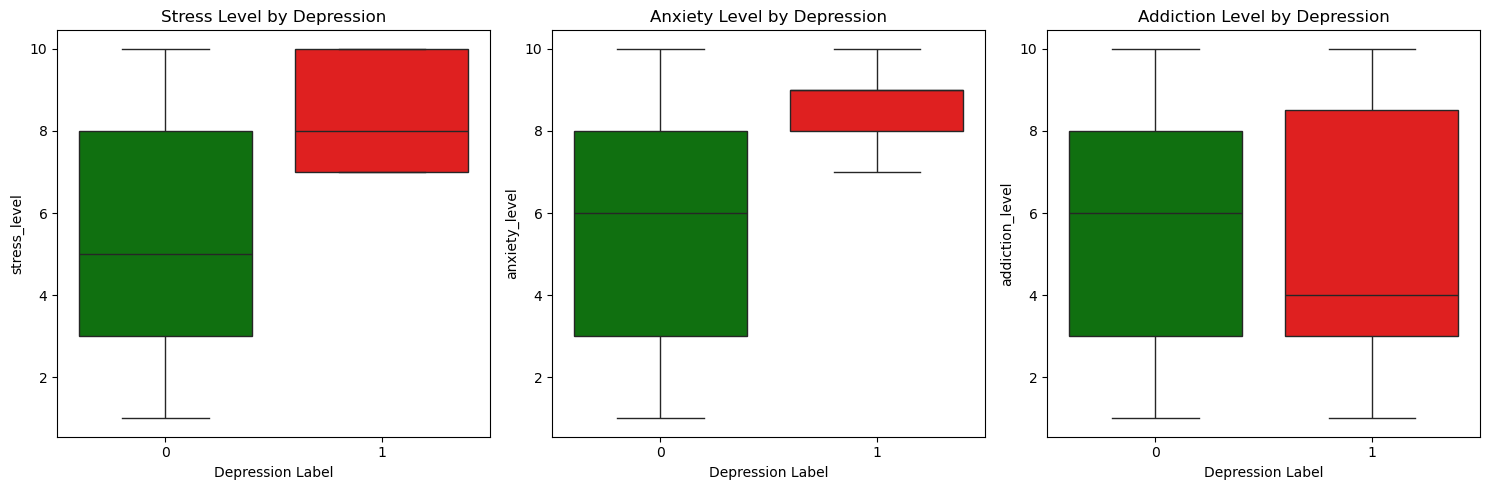

In [19]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(metrics):
    sns.boxplot(x='depression_label', y=metric, data=df, ax=axes[i], palette=['green', 'red'])
    axes[i].set_title(f'{metric.replace("_", " ").title()} by Depression')
    axes[i].set_xlabel('Depression Label')

plt.tight_layout()
plt.show()

## Social Interaction Level Analysis

In [20]:
print("="*50)
print("SOCIAL INTERACTION ANALYSIS:")
print("="*50)

# Social interaction distribution
interaction_counts = df['social_interaction_level'].value_counts()
print("Social Interaction Levels:")
print(interaction_counts)

# Depression by social interaction
interaction_depression = pd.crosstab(df['social_interaction_level'], df['depression_label'], normalize='index') * 100
print("\nDepression Rate by Social Interaction Level:")
print(interaction_depression)


SOCIAL INTERACTION ANALYSIS:
Social Interaction Levels:
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

Depression Rate by Social Interaction Level:
depression_label                  0         1
social_interaction_level                     
high                      97.289973  2.710027
low                       97.831325  2.168675
medium                    97.115385  2.884615


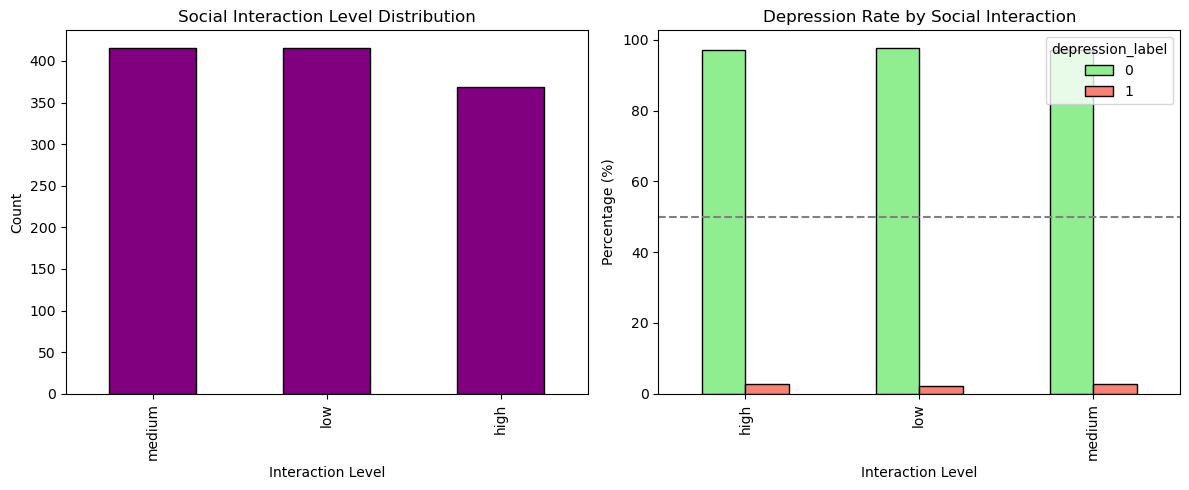

In [21]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

interaction_counts.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black')
axes[0].set_title('Social Interaction Level Distribution')
axes[0].set_xlabel('Interaction Level')
axes[0].set_ylabel('Count')

interaction_depression.plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'], edgecolor='black')
axes[1].set_title('Depression Rate by Social Interaction')
axes[1].set_xlabel('Interaction Level')
axes[1].set_ylabel('Percentage (%)')
axes[1].axhline(y=50, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

## Age Analysis

In [22]:
print("="*50)
print("AGE ANALYSIS:")
print("="*50)

print(f"Age range: {df['age'].min()} to {df['age'].max()} years")
print(f"Average age: {df['age'].mean():.2f} years")

# Age group vs Depression
age_depression = pd.crosstab(df['age'], df['depression_label'], normalize='index') * 100
print("\nDepression Rate by Age:")
print(age_depression)

AGE ANALYSIS:
Age range: 13 to 19 years
Average age: 15.93 years

Depression Rate by Age:
depression_label          0         1
age                                  
13                98.000000  2.000000
14                98.039216  1.960784
15                95.555556  4.444444
16                97.546012  2.453988
17                98.823529  1.176471
18                97.674419  2.325581
19                96.296296  3.703704


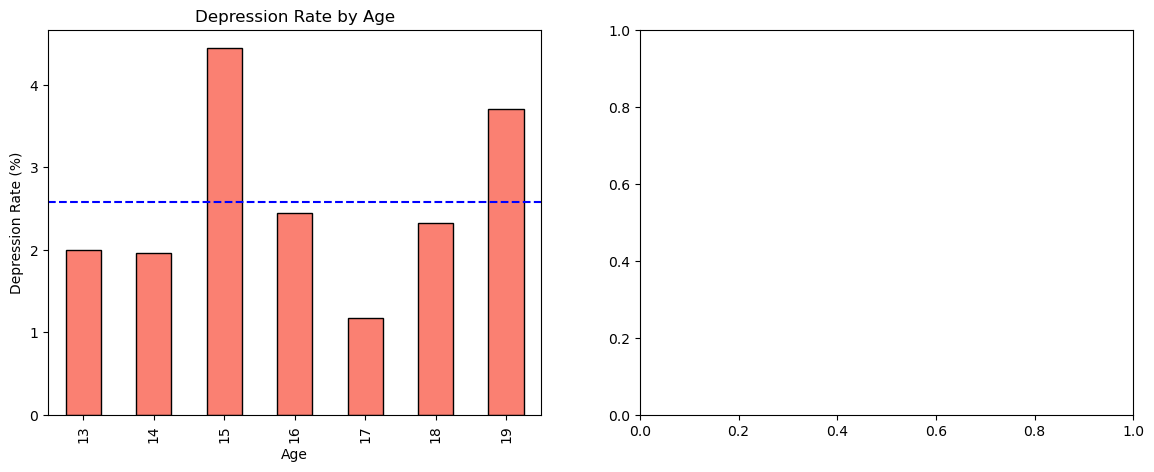

In [23]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Depression rate by age
age_depression[1].plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Depression Rate by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Depression Rate (%)')
axes[0].axhline(y=age_depression[1].mean(), color='blue', linestyle='--', label='Average')

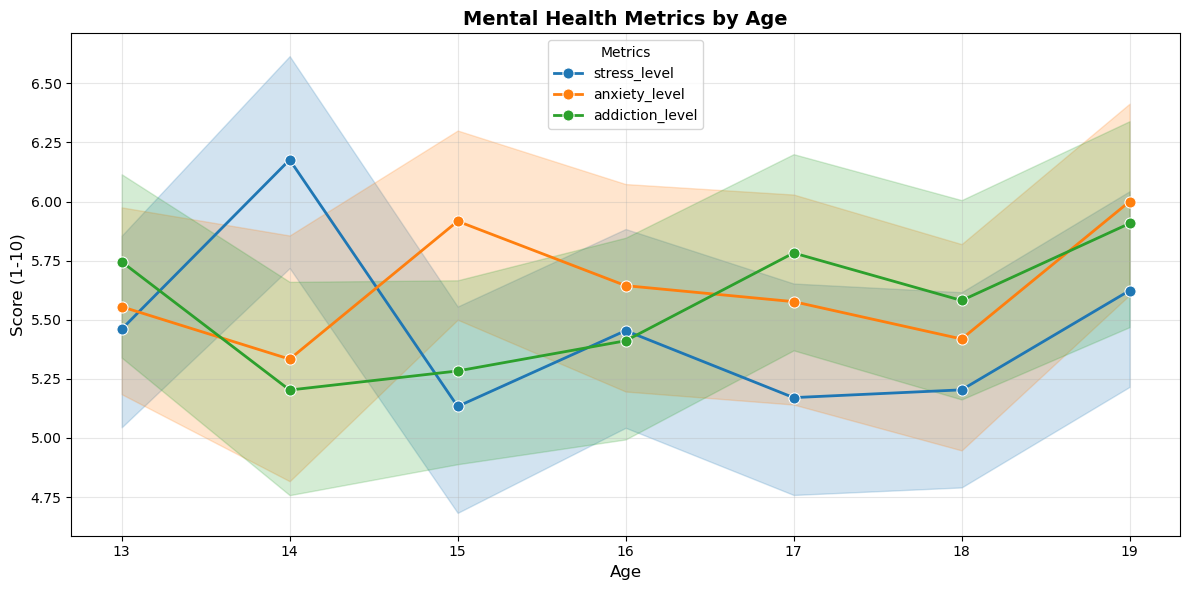

In [24]:
# Create melted dataframe
df_melted_age = df.melt(id_vars=['age'], value_vars=['stress_level', 'anxiety_level', 'addiction_level'])

# Create plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='value', hue='variable', data=df_melted_age, marker='o', markersize=8, linewidth=2)

# Customize
plt.title('Mental Health Metrics by Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Score (1-10)', fontsize=12)
plt.legend(title='Metrics')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Academic Performance Analysis

In [25]:
print("="*50)
print("ACADEMIC PERFORMANCE ANALYSIS:")
print("="*50)

print(f"Average academic performance score: {df['academic_performance'].mean():.2f}")

# Compare by depression
depressed_academic = df[df['depression_label'] == 1]['academic_performance'].mean()
non_depressed_academic = df[df['depression_label'] == 0]['academic_performance'].mean()
print(f"\nDepressed teens academic score: {depressed_academic:.2f}")
print(f"Non-depressed teens academic score: {non_depressed_academic:.2f}")

# Create academic categories
df['academic_category'] = pd.cut(df['academic_performance'], 
                                  bins=[0, 2.5, 3.5, 4.1], 
                                  labels=['Low', 'Medium', 'High'])

academic_depression = pd.crosstab(df['academic_category'], df['depression_label'], normalize='index') * 100
print("\nDepression Rate by Academic Performance:")
print(academic_depression)

ACADEMIC PERFORMANCE ANALYSIS:
Average academic performance score: 2.99

Depressed teens academic score: 3.00
Non-depressed teens academic score: 2.99

Depression Rate by Academic Performance:
depression_label           0         1
academic_category                     
Low                97.368421  2.631579
Medium             97.545008  2.454992
High               97.192982  2.807018


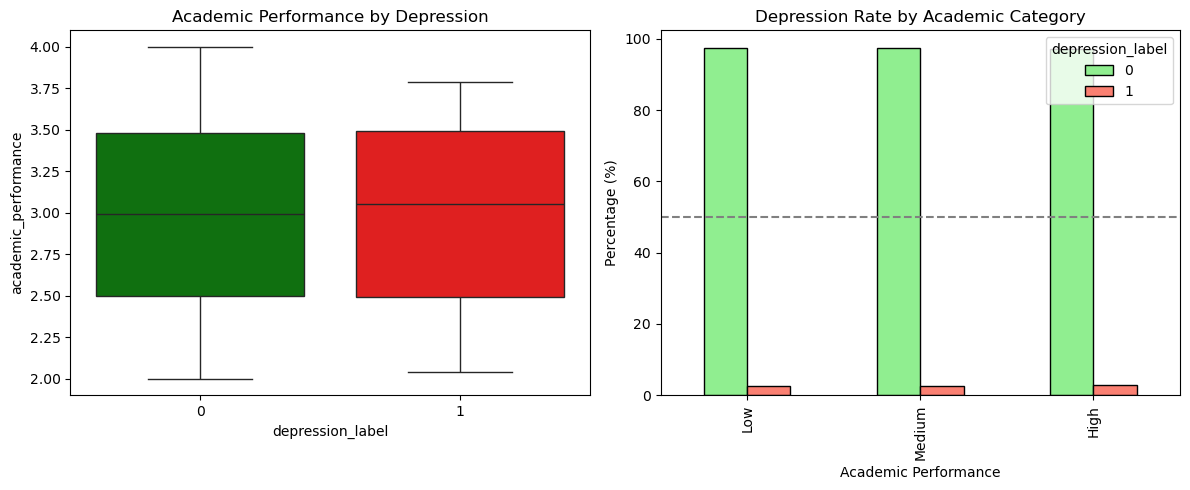

In [26]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='depression_label', y='academic_performance', data=df, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Academic Performance by Depression')

academic_depression.plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'], edgecolor='black')
axes[1].set_title('Depression Rate by Academic Category')
axes[1].set_xlabel('Academic Performance')
axes[1].set_ylabel('Percentage (%)')
axes[1].axhline(y=50, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

## Physical Activity Analysis

In [27]:
print("="*50)
print("PHYSICAL ACTIVITY ANALYSIS:")
print("="*50)

print(f"Average physical activity score: {df['physical_activity'].mean():.2f}")

# Compare by depression
depressed_activity = df[df['depression_label'] == 1]['physical_activity'].mean()
non_depressed_activity = df[df['depression_label'] == 0]['physical_activity'].mean()
print(f"\nDepressed teens physical activity: {depressed_activity:.2f}")
print(f"Non-depressed teens physical activity: {non_depressed_activity:.2f}")

PHYSICAL ACTIVITY ANALYSIS:
Average physical activity score: 1.01

Depressed teens physical activity: 0.95
Non-depressed teens physical activity: 1.02


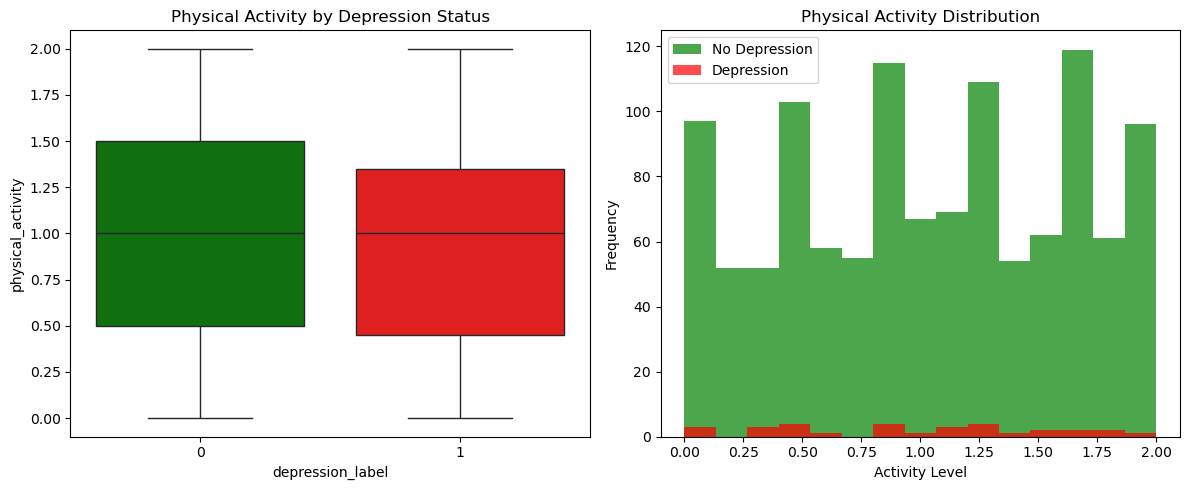

In [28]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='depression_label', y='physical_activity', data=df, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Physical Activity by Depression Status')

# Histogram
axes[1].hist(df[df['depression_label']==0]['physical_activity'], bins=15, alpha=0.7, label='No Depression', color='green')
axes[1].hist(df[df['depression_label']==1]['physical_activity'], bins=15, alpha=0.7, label='Depression', color='red')
axes[1].set_title('Physical Activity Distribution')
axes[1].set_xlabel('Activity Level')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

## Correlation Analysis

In [29]:
print("="*50)
print("CORRELATION ANALYSIS:")
print("="*50)

# Select numerical columns for correlation
numerical_cols = ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                  'academic_performance', 'physical_activity', 'stress_level', 
                  'anxiety_level', 'addiction_level', 'age']

# Calculate correlation with depression
correlation = df[numerical_cols + ['depression_label']].corr()['depression_label'].sort_values(ascending=False)

print("Correlation with Depression Label:")
print(correlation)

CORRELATION ANALYSIS:
Correlation with Depression Label:
depression_label            1.000000
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
age                         0.010973
academic_performance        0.001441
addiction_level            -0.013952
screen_time_before_sleep   -0.016502
physical_activity          -0.017598
sleep_hours                -0.190630
Name: depression_label, dtype: float64


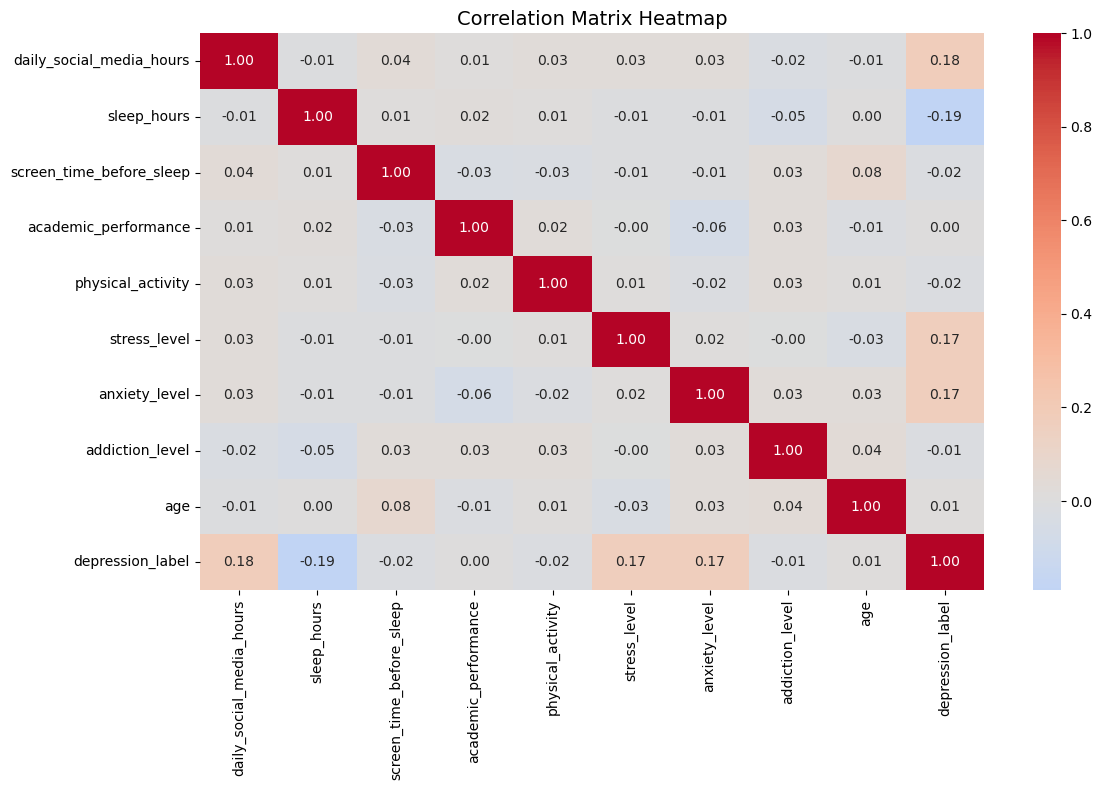

In [30]:
# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols + ['depression_label']].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## High Risk Factor Analysis

In [31]:
print("="*50)
print("HIGH RISK FACTORS ANALYSIS:")
print("="*50)

# Create risk categories
df['high_social_media'] = df['daily_social_media_hours'] > 6
df['poor_sleep'] = df['sleep_hours'] < 6
df['high_stress'] = df['stress_level'] > 7
df['high_anxiety'] = df['anxiety_level'] > 7

# Calculate depression rate for each risk factor
risk_factors = ['high_social_media', 'poor_sleep', 'high_stress', 'high_anxiety']

for risk in risk_factors:
    depression_rate = df[df[risk] == True]['depression_label'].mean() * 100
    normal_rate = df[df[risk] == False]['depression_label'].mean() * 100
    print(f"\n{risk.replace('_', ' ').title()}:")
    print(f"  With risk factor: {depression_rate:.1f}% depression rate")
    print(f"  Without risk factor: {normal_rate:.1f}% depression rate")

HIGH RISK FACTORS ANALYSIS:

High Social Media:
  With risk factor: 6.5% depression rate
  Without risk factor: 1.0% depression rate

Poor Sleep:
  With risk factor: 6.5% depression rate
  Without risk factor: 0.0% depression rate

High Stress:
  With risk factor: 6.2% depression rate
  Without risk factor: 1.1% depression rate

High Anxiety:
  With risk factor: 6.5% depression rate
  Without risk factor: 0.7% depression rate


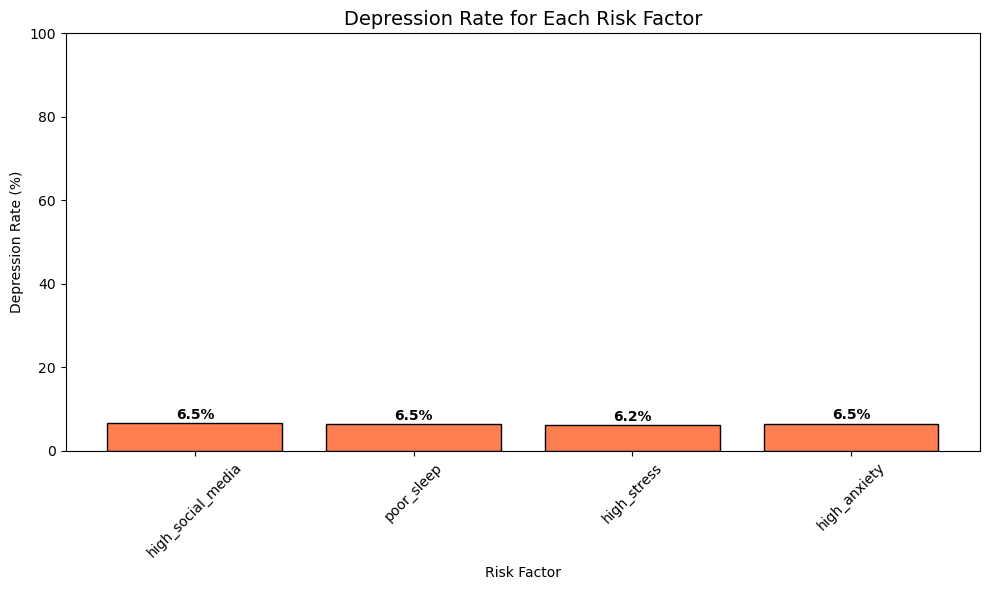

In [32]:
# Visualization
risk_depression = {}
for risk in risk_factors:
    risk_depression[risk] = df[df[risk] == True]['depression_label'].mean() * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(risk_depression.keys(), risk_depression.values(), color='coral', edgecolor='black')
plt.title('Depression Rate for Each Risk Factor', fontsize=14)
plt.xlabel('Risk Factor')
plt.ylabel('Depression Rate (%)')
plt.ylim(0, 100)
for bar, value in zip(bars, risk_depression.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Multiple Risk Factors Analysis

In [33]:
print("="*50)
print("MULTIPLE RISK FACTORS ANALYSIS:")
print("="*50)

# Count risk factors per student
df['risk_count'] = df[risk_factors].sum(axis=1)

# Depression rate by number of risk factors
risk_count_depression = df.groupby('risk_count')['depression_label'].mean() * 100
print("Depression Rate by Number of Risk Factors:")
print(risk_count_depression)

MULTIPLE RISK FACTORS ANALYSIS:
Depression Rate by Number of Risk Factors:
risk_count
0      0.000000
1      0.230415
2      1.675978
3      7.826087
4    100.000000
Name: depression_label, dtype: float64


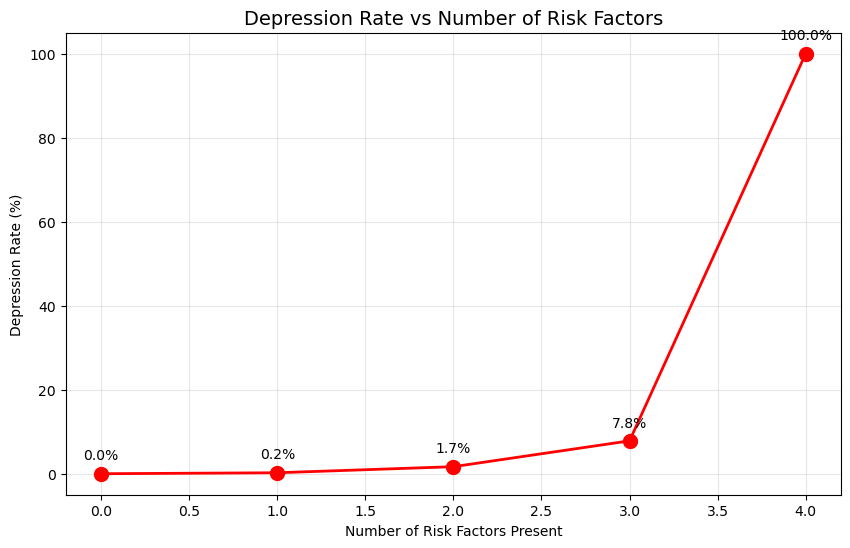

In [34]:
# Visualization
plt.figure(figsize=(10, 6))
plt.plot(risk_count_depression.index, risk_count_depression.values, marker='o', linewidth=2, markersize=10, color='red')
plt.title('Depression Rate vs Number of Risk Factors', fontsize=14)
plt.xlabel('Number of Risk Factors Present')
plt.ylabel('Depression Rate (%)')
plt.grid(True, alpha=0.3)
for i, value in enumerate(risk_count_depression.values):
    plt.annotate(f'{value:.1f}%', (i, value), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

## Final Summary Report

In [35]:
print("="*60)
print("FINAL SUMMARY REPORT")
print("="*60)

print("\n📊 DATASET OVERVIEW:")
print(f"   • Total Students: {len(df)}")
print(f"   • Age Range: {df['age'].min()}-{df['age'].max()} years")
print(f"   • Depression Rate: {(df['depression_label'].sum()/len(df))*100:.1f}%")

print("\n📱 SOCIAL MEDIA:")
print(f"   • Average Daily Usage: {df['daily_social_media_hours'].mean():.1f} hours")
print(f"   • Most Used Platform: {df['platform_usage'].mode()[0]}")
print(f"   • Depressed teens use {depressed_hours - non_depressed_hours:.1f} more hours/day")

print("\n😴 SLEEP PATTERNS:")
print(f"   • Average Sleep: {df['sleep_hours'].mean():.1f} hours")
print(f"   • Depressed teens sleep {non_depressed_sleep - depressed_sleep:.1f} fewer hours")

print("\n🧠 MENTAL HEALTH METRICS (1-10 scale):")
for metric in metrics:
    print(f"   • {metric.replace('_', ' ').title()}: {df[metric].mean():.1f}/10")

print("\n⚠️ KEY RISK FACTORS:")
for risk in risk_factors:
    rate = df[df[risk] == True]['depression_label'].mean() * 100
    print(f"   • {risk.replace('_', ' ').title()}: {rate:.1f}% depression rate")

print("\n💡 RECOMMENDATIONS:")
print("   1. Reduce social media usage to <6 hours/day")
print("   2. Ensure at least 7 hours of sleep")
print("   3. Maintain high social interaction levels")
print("   4. Monitor stress and anxiety levels regularly")
print("   5. Encourage physical activity")

# Save summary to CSV
summary_data = {
    'Metric': ['Total Students', 'Average Age', 'Depression Rate (%)', 
               'Avg Social Media Hours', 'Avg Sleep Hours', 'Avg Stress Level',
               'Avg Anxiety Level', 'Avg Addiction Level'],
    'Value': [len(df), df['age'].mean(), (df['depression_label'].sum()/len(df))*100,
              df['daily_social_media_hours'].mean(), df['sleep_hours'].mean(),
              df['stress_level'].mean(), df['anxiety_level'].mean(), df['addiction_level'].mean()]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('mental_health_summary.csv', index=False)
print("\n✅ Summary saved to 'mental_health_summary.csv'")

FINAL SUMMARY REPORT

📊 DATASET OVERVIEW:
   • Total Students: 1200
   • Age Range: 13-19 years
   • Depression Rate: 2.6%

📱 SOCIAL MEDIA:
   • Average Daily Usage: 4.5 hours
   • Most Used Platform: Instagram
   • Depressed teens use 2.2 more hours/day

😴 SLEEP PATTERNS:
   • Average Sleep: 6.4 hours
   • Depressed teens sleep 1.7 fewer hours

🧠 MENTAL HEALTH METRICS (1-10 scale):
   • Stress Level: 5.4/10
   • Anxiety Level: 5.6/10
   • Addiction Level: 5.6/10

⚠️ KEY RISK FACTORS:
   • High Social Media: 6.5% depression rate
   • Poor Sleep: 6.5% depression rate
   • High Stress: 6.2% depression rate
   • High Anxiety: 6.5% depression rate

💡 RECOMMENDATIONS:
   1. Reduce social media usage to <6 hours/day
   2. Ensure at least 7 hours of sleep
   3. Maintain high social interaction levels
   4. Monitor stress and anxiety levels regularly
   5. Encourage physical activity

✅ Summary saved to 'mental_health_summary.csv'
